In [10]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120



In [11]:
# oad processed data
df = pd.read_csv("../../data/processed/spam_processed.csv")

# Ensure that no NaN values exist in the text column
df["text_clean"] = df["text_clean"].fillna("")

print(f"Shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

Shape: (5169, 7)
Label distribution:
label
0    4516
1     653
Name: count, dtype: int64


In [12]:
# CELL 3: TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,   # keep top 5000 features
    ngram_range=(1, 2),  # use unigrams and bigrams
    stop_words="english" # remove English stop words
)

X = tfidf.fit_transform(df["text_clean"])
y = df["label"]

print(f"Feature matrix shape: {X.shape}")
print(f"  → {X.shape[0]} messages, {X.shape[1]} features")

Feature matrix shape: (5169, 5000)
  → 5169 messages, 5000 features


In [13]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keep the spam/ham ratio
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"\nTrain label distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTest label distribution:\n{pd.Series(y_test).value_counts()}")

Train size : 4135
Test size  : 1034

Train label distribution:
label
0    3613
1     522
Name: count, dtype: int64

Test label distribution:
label
0    903
1    131
Name: count, dtype: int64


In [14]:
# Train Model 1 Multinomial Naive Bayes
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Results")
print(f"Accuracy : {accuracy_score(y_test, nb_pred):.4f}")
print(f"Precision: {precision_score(y_test, nb_pred):.4f}")
print(f"Recall   : {recall_score(y_test, nb_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, nb_pred):.4f}")

Naive Bayes Results
Accuracy : 0.9845
Precision: 0.9832
Recall   : 0.8931
F1 Score : 0.9360


In [15]:
# CELL 6: Train Model 2 — Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print(f"Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall   : {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, lr_pred):.4f}")

Logistic Regression Results
Accuracy : 0.9391
Precision: 0.9857
Recall   : 0.5267
F1 Score : 0.6866


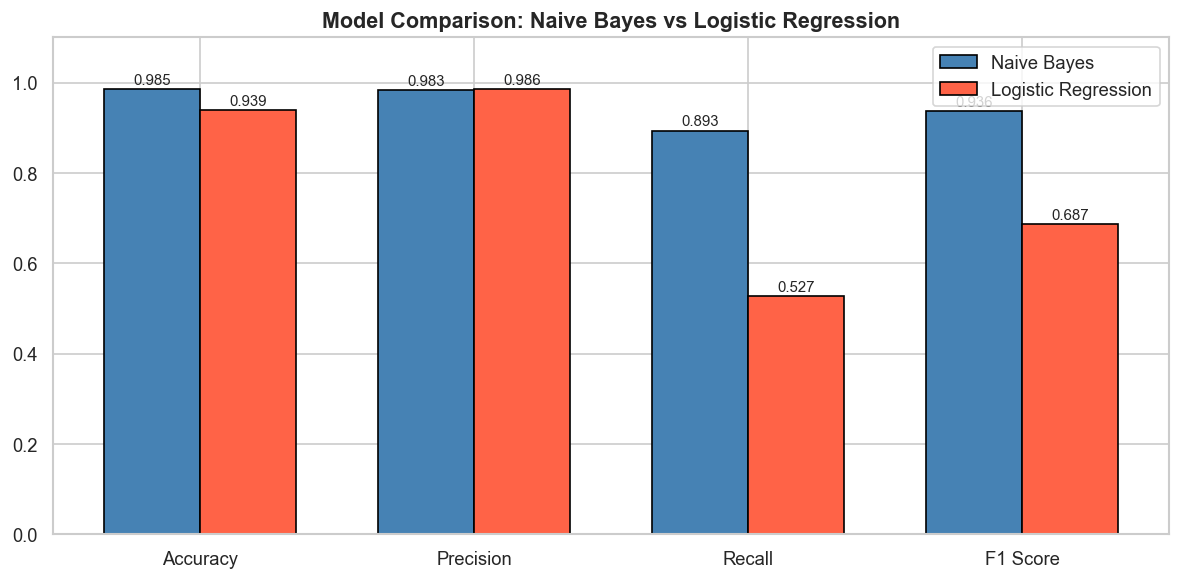

In [16]:
# Compare models by bar chart
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

nb_scores = [
    accuracy_score(y_test, nb_pred),
    precision_score(y_test, nb_pred),
    recall_score(y_test, nb_pred),
    f1_score(y_test, nb_pred)
]
lr_scores = [
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred),
    recall_score(y_test, lr_pred),
    f1_score(y_test, lr_pred)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, nb_scores, width, label="Naive Bayes",
               color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, lr_scores, width, label="Logistic Regression",
               color="tomato", edgecolor="black")

# Add numbers on top of each bar
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Model Comparison: Naive Bayes vs Logistic Regression",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

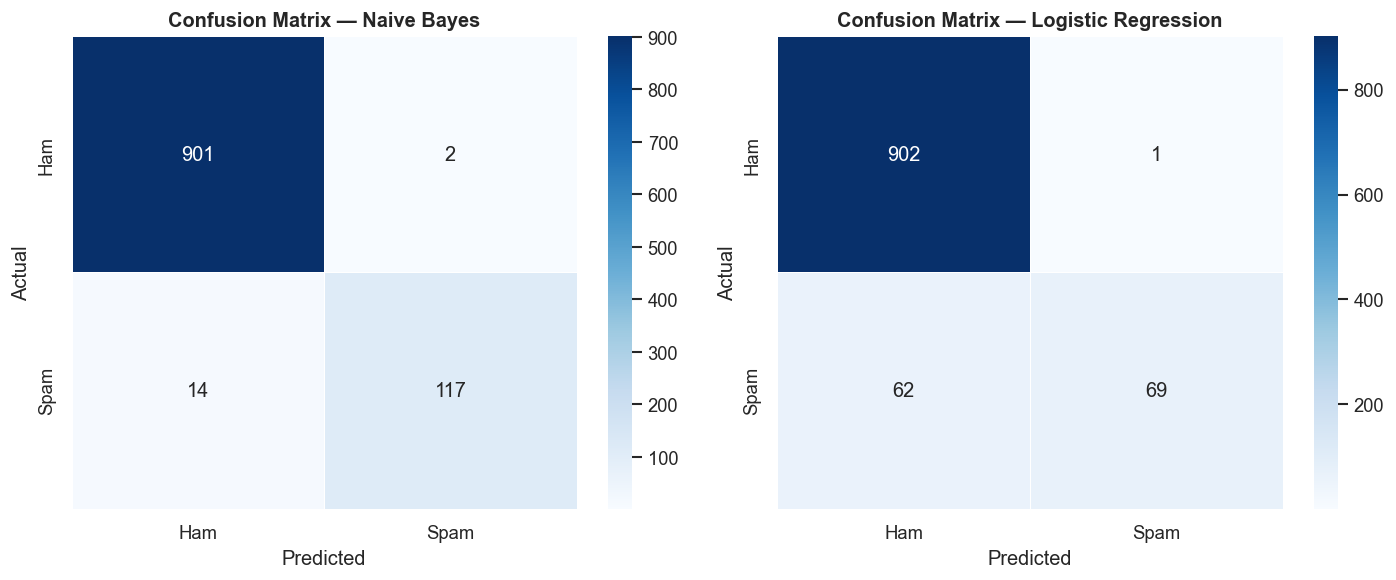

In [17]:
# Confusion Matrix — both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(
    axes,
    [nb_pred, lr_pred],
    ["Naive Bayes", "Logistic Regression"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Ham", "Spam"],
                yticklabels=["Ham", "Spam"],
                ax=ax, linewidths=0.5)
    ax.set_title(f"Confusion Matrix — {title}",
                 fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [18]:
# Cross Validation (5-fold)
print(" 5-Fold Cross Validation \n")

for name, model in [("Naive Bayes", nb_model),
                    ("Logistic Regression", lr_model)]:
    scores = cross_val_score(model, X, y, cv=5, scoring="f1")
    print(f"{name}:")
    print(f"  F1 per fold : {scores.round(4)}")
    print(f"  Mean F1     : {scores.mean():.4f}")
    print(f"  Std         : {scores.std():.4f}\n")

 5-Fold Cross Validation 

Naive Bayes:
  F1 per fold : [0.9531 0.9106 0.9069 0.9237 0.9127]
  Mean F1     : 0.9214
  Std         : 0.0168

Logistic Regression:
  F1 per fold : [0.8091 0.6633 0.7282 0.7087 0.7547]
  Mean F1     : 0.7328
  Std         : 0.0484



In [19]:
#  Select best model & Save
nb_f1 = f1_score(y_test, nb_pred)
lr_f1 = f1_score(y_test, lr_pred)

best_model = nb_model if nb_f1 >= lr_f1 else lr_model
best_name  = "Naive Bayes" if nb_f1 >= lr_f1 else "Logistic Regression"

print(f"Naive Bayes F1     : {nb_f1:.4f}")
print(f"Logistic Regression F1: {lr_f1:.4f}")
print(f"\n Best model: {best_name}")

# save model & tfidf vectorizer
os.makedirs("../../models", exist_ok=True)

with open("../../models/spam_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("../../models/spam_tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("\nSaved:")
print("  models/spam_model.pkl")
print("  models/spam_tfidf.pkl")

Naive Bayes F1     : 0.9360
Logistic Regression F1: 0.6866

 Best model: Naive Bayes

Saved:
  models/spam_model.pkl
  models/spam_tfidf.pkl
